In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')
# --- تحميل البيانات ---
X = np.load('/content/drive/MyDrive/alphabet/images_over.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_over.npy')

# لو الصور رمادية نكررها لثلاث قنوات
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# تقسيم البيانات
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

input_shape = X_train.shape[1:]
num_classes = len(np.unique(y))


Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Fine-tuning: نفتح آخر 20 طبقة
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers[-20:]:
        layer.trainable = True

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model



🚀 Run 1/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 99s 110ms/step - accuracy: 0.2450 - loss: 3.1066 - val_accuracy: 0.5294 - val_loss: 1.6524 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.6605 - loss: 1.0871 - val_accuracy: 0.7414 - val_loss: 0.8993 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.7803 - loss: 0.6827 - val_accuracy: 0.8465 - val_loss: 0.5018 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.8436 - loss: 0.4758 - val_accuracy: 0.9149 - val_loss: 0.2627 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.8817 - loss: 0.3655 - val_accuracy: 0.9358 - val_loss: 0.2073 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.9071 - loss: 0.2891 - val_accuracy: 0.9503 - val_loss: 0.1609 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accura

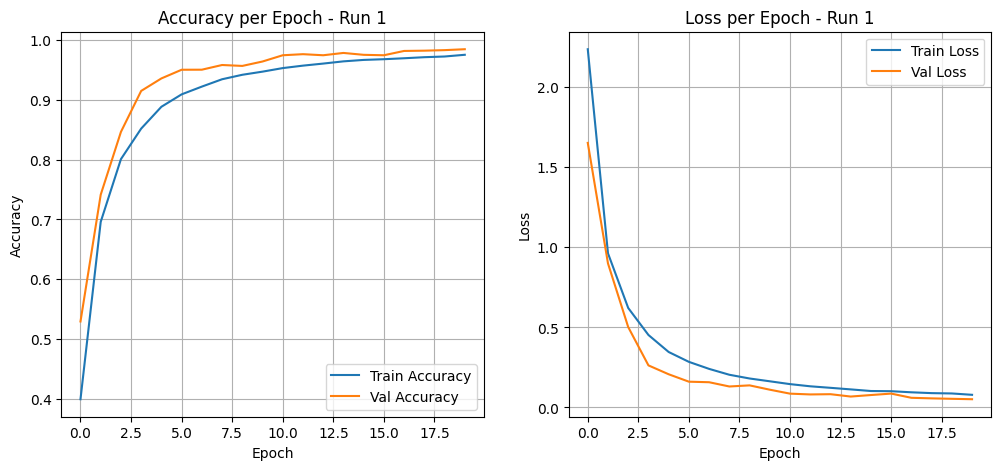

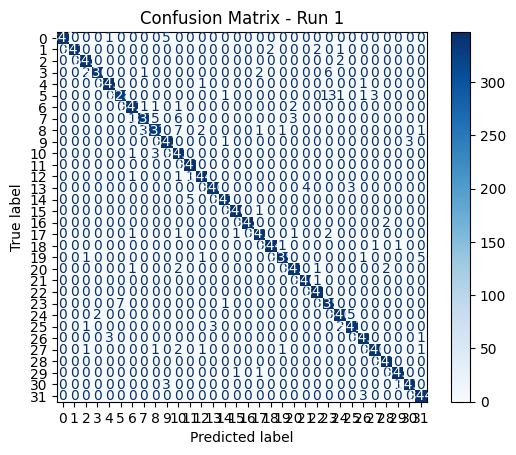


🚀 Run 2/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 78s 94ms/step - accuracy: 0.2426 - loss: 3.1206 - val_accuracy: 0.5312 - val_loss: 1.6939 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.6638 - loss: 1.0726 - val_accuracy: 0.7686 - val_loss: 0.7668 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7814 - loss: 0.6813 - val_accuracy: 0.8539 - val_loss: 0.4644 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.8436 - loss: 0.4872 - val_accuracy: 0.9097 - val_loss: 0.2665 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.8812 - loss: 0.3662 - val_accuracy: 0.9230 - val_loss: 0.2355 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.9020 - loss: 0.3083 - val_accuracy: 0.9407 - val_loss: 0.1786 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accurac

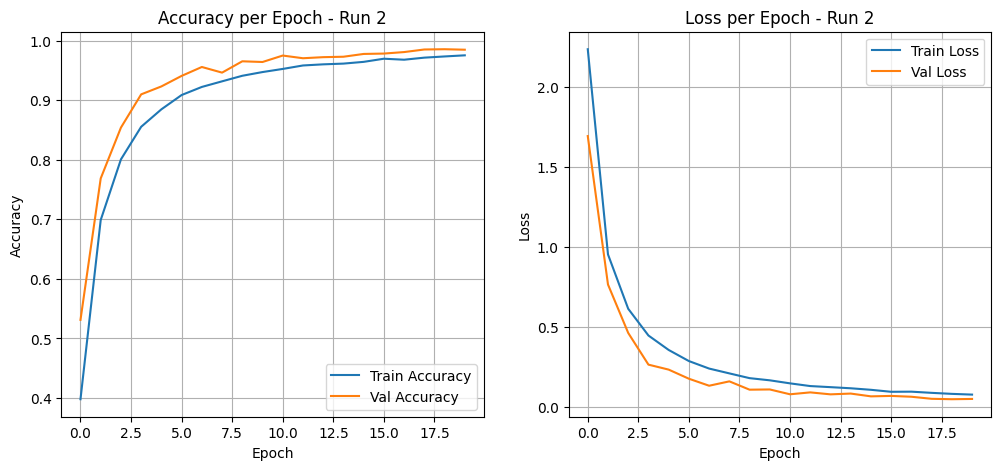

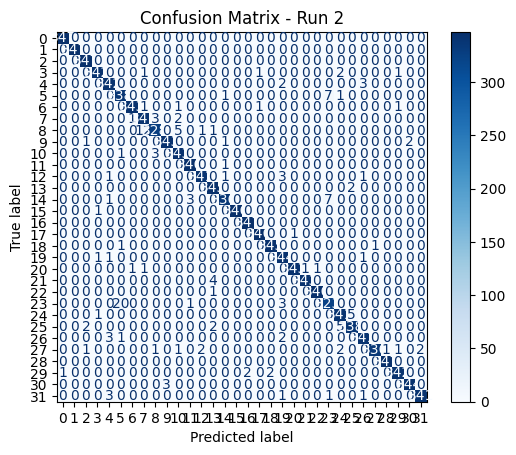


🚀 Run 3/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 80s 95ms/step - accuracy: 0.2422 - loss: 3.1401 - val_accuracy: 0.5648 - val_loss: 1.5173 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 60s 87ms/step - accuracy: 0.6578 - loss: 1.0952 - val_accuracy: 0.7768 - val_loss: 0.7302 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.7810 - loss: 0.6776 - val_accuracy: 0.8607 - val_loss: 0.4369 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.8389 - loss: 0.4936 - val_accuracy: 0.9059 - val_loss: 0.2854 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.8853 - loss: 0.3628 - val_accuracy: 0.9384 - val_loss: 0.1930 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.9010 - loss: 0.3043 - val_accuracy: 0.9506 - val_loss: 0.1548 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accurac

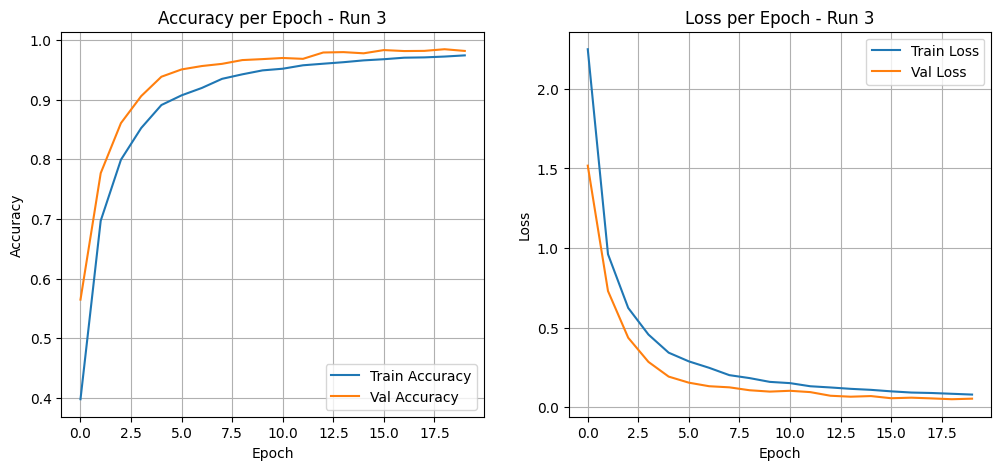

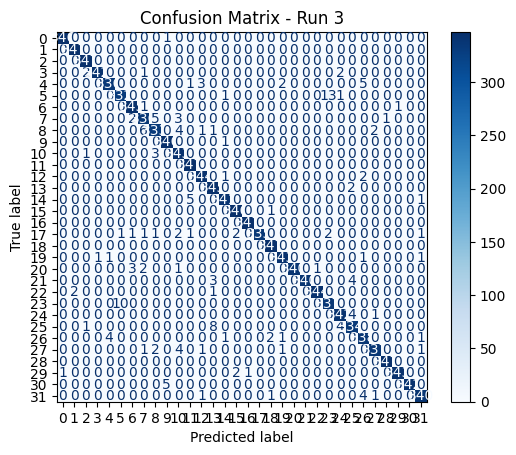


🚀 Run 4/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 85s 104ms/step - accuracy: 0.2346 - loss: 3.1755 - val_accuracy: 0.5440 - val_loss: 1.7025 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 95ms/step - accuracy: 0.6532 - loss: 1.1184 - val_accuracy: 0.7517 - val_loss: 0.8658 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.7753 - loss: 0.6985 - val_accuracy: 0.8538 - val_loss: 0.4602 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 66s 95ms/step - accuracy: 0.8407 - loss: 0.4935 - val_accuracy: 0.8987 - val_loss: 0.3045 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.8780 - loss: 0.3818 - val_accuracy: 0.9328 - val_loss: 0.2062 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.9025 - loss: 0.3088 - val_accuracy: 0.9487 - val_loss: 0.1546 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accura

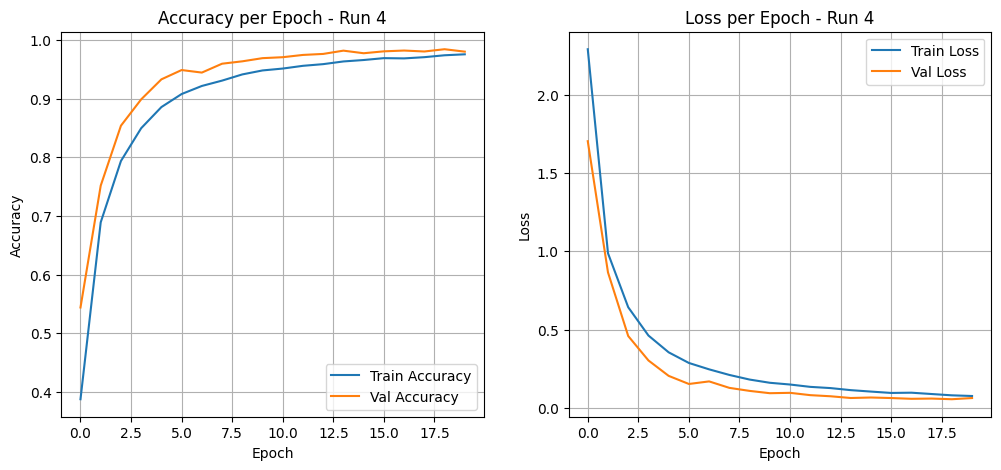

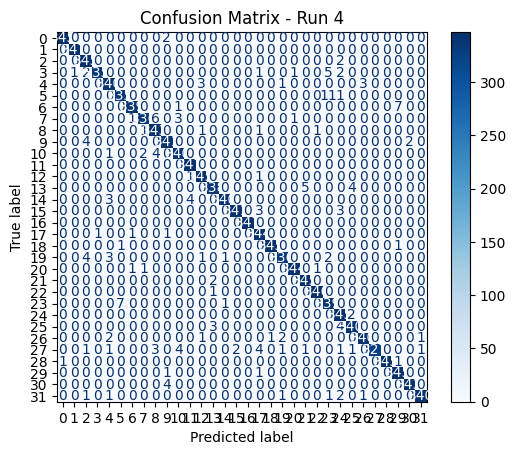


🚀 Run 5/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 85s 103ms/step - accuracy: 0.2445 - loss: 3.1154 - val_accuracy: 0.5710 - val_loss: 1.5125 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.6657 - loss: 1.0741 - val_accuracy: 0.7524 - val_loss: 0.8302 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 64s 92ms/step - accuracy: 0.7796 - loss: 0.6886 - val_accuracy: 0.8618 - val_loss: 0.4311 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.8469 - loss: 0.4842 - val_accuracy: 0.9097 - val_loss: 0.2818 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.8782 - loss: 0.3712 - val_accuracy: 0.9398 - val_loss: 0.1896 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.9031 - loss: 0.3007 - val_accuracy: 0.9488 - val_loss: 0.1597 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accura

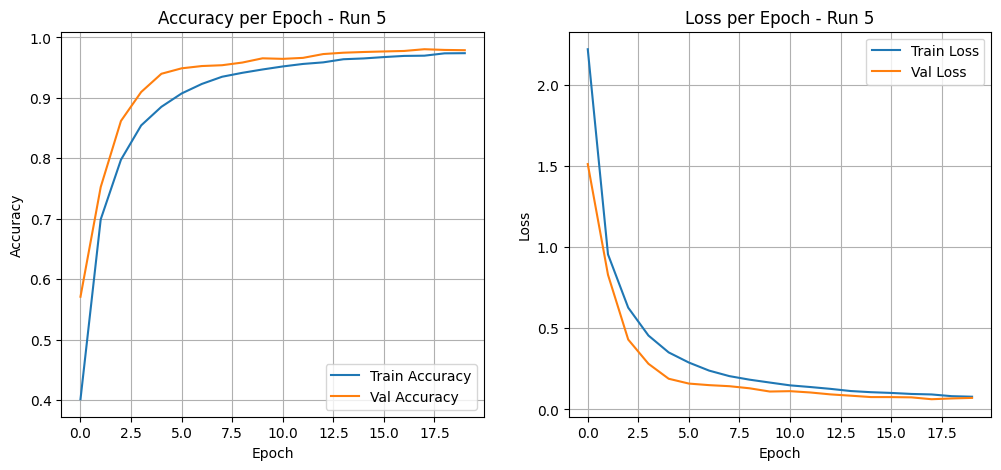

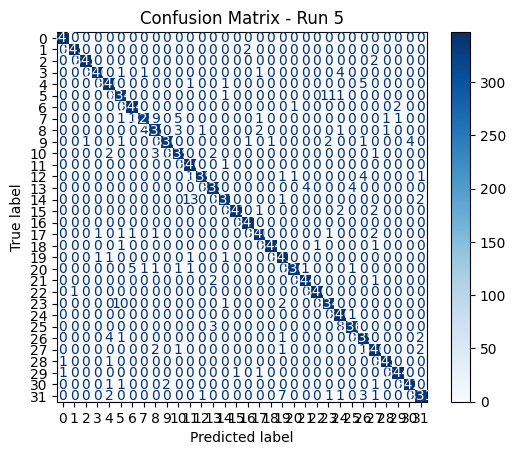


🚀 Run 6/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 85s 102ms/step - accuracy: 0.2410 - loss: 3.1524 - val_accuracy: 0.5522 - val_loss: 1.5166 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.6531 - loss: 1.1258 - val_accuracy: 0.7704 - val_loss: 0.7331 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.7783 - loss: 0.6922 - val_accuracy: 0.8728 - val_loss: 0.3916 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.8436 - loss: 0.4927 - val_accuracy: 0.9201 - val_loss: 0.2466 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.8779 - loss: 0.3736 - val_accuracy: 0.9356 - val_loss: 0.1974 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.9033 - loss: 0.3066 - val_accuracy: 0.9498 - val_loss: 0.1552 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/st

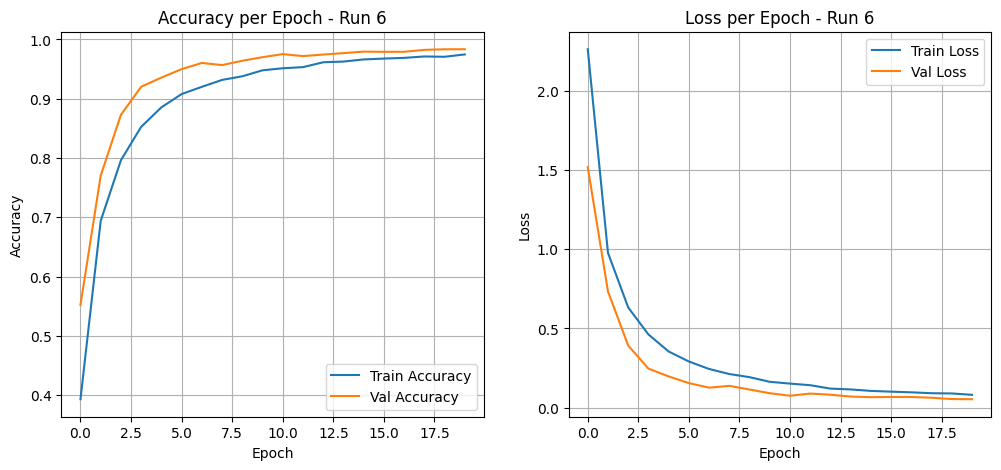

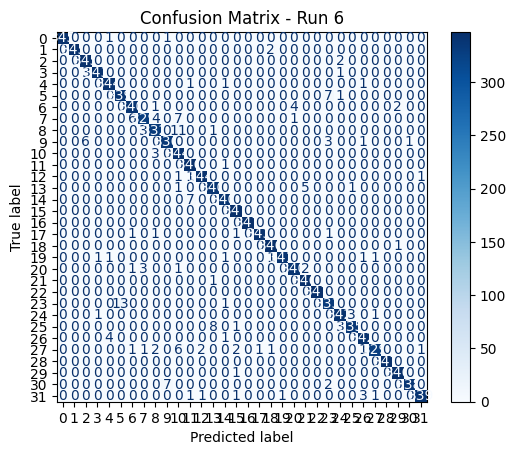


🚀 Run 7/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 87s 105ms/step - accuracy: 0.2412 - loss: 3.1352 - val_accuracy: 0.5529 - val_loss: 1.4915 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.6566 - loss: 1.0850 - val_accuracy: 0.7713 - val_loss: 0.7649 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.7808 - loss: 0.6821 - val_accuracy: 0.8758 - val_loss: 0.3945 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.8437 - loss: 0.4782 - val_accuracy: 0.9060 - val_loss: 0.2896 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.8799 - loss: 0.3722 - val_accuracy: 0.9189 - val_loss: 0.2437 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - accuracy: 0.9013 - loss: 0.3081 - val_accuracy: 0.9336 - val_loss: 0.2109 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accura

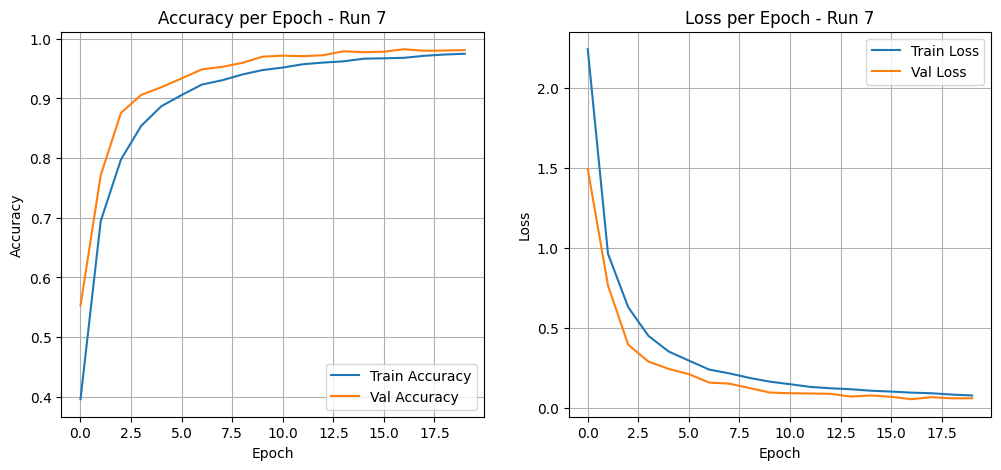

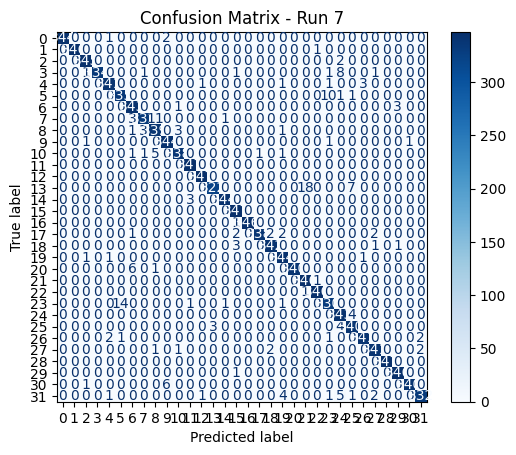


🚀 Run 8/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 88s 106ms/step - accuracy: 0.2396 - loss: 3.1475 - val_accuracy: 0.5705 - val_loss: 1.4324 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.6618 - loss: 1.0877 - val_accuracy: 0.7982 - val_loss: 0.6376 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 100ms/step - accuracy: 0.7754 - loss: 0.7040 - val_accuracy: 0.8768 - val_loss: 0.3709 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.8423 - loss: 0.4962 - val_accuracy: 0.9270 - val_loss: 0.2267 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 97ms/step - accuracy: 0.8801 - loss: 0.3764 - val_accuracy: 0.9332 - val_loss: 0.2051 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.9037 - loss: 0.3029 - val_accuracy: 0.9500 - val_loss: 0.1555 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accu

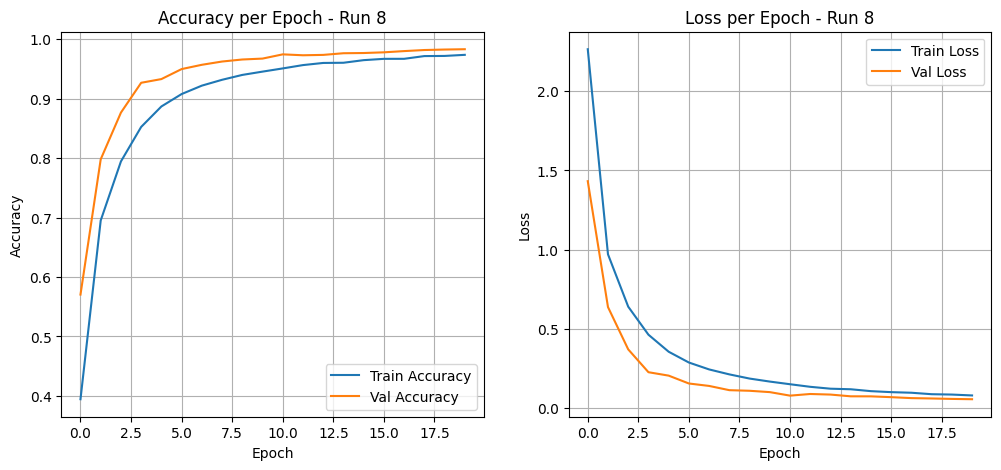

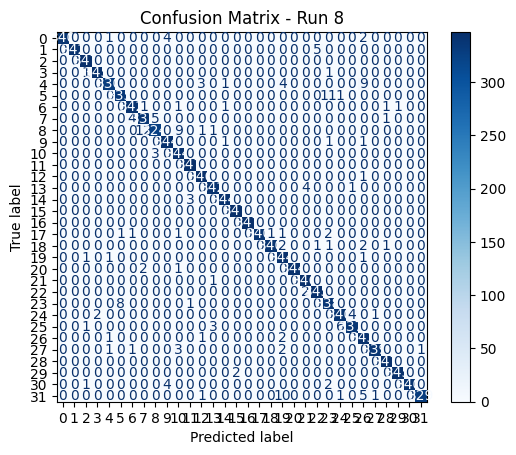


🚀 Run 9/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 86s 105ms/step - accuracy: 0.2456 - loss: 3.1019 - val_accuracy: 0.5757 - val_loss: 1.4770 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 67s 97ms/step - accuracy: 0.6614 - loss: 1.0764 - val_accuracy: 0.7651 - val_loss: 0.7847 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.7845 - loss: 0.6638 - val_accuracy: 0.8609 - val_loss: 0.4487 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accuracy: 0.8480 - loss: 0.4771 - val_accuracy: 0.9086 - val_loss: 0.2769 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.8817 - loss: 0.3682 - val_accuracy: 0.9287 - val_loss: 0.2211 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 99ms/step - accuracy: 0.9054 - loss: 0.2946 - val_accuracy: 0.9376 - val_loss: 0.1993 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 69s 99ms/step - accur

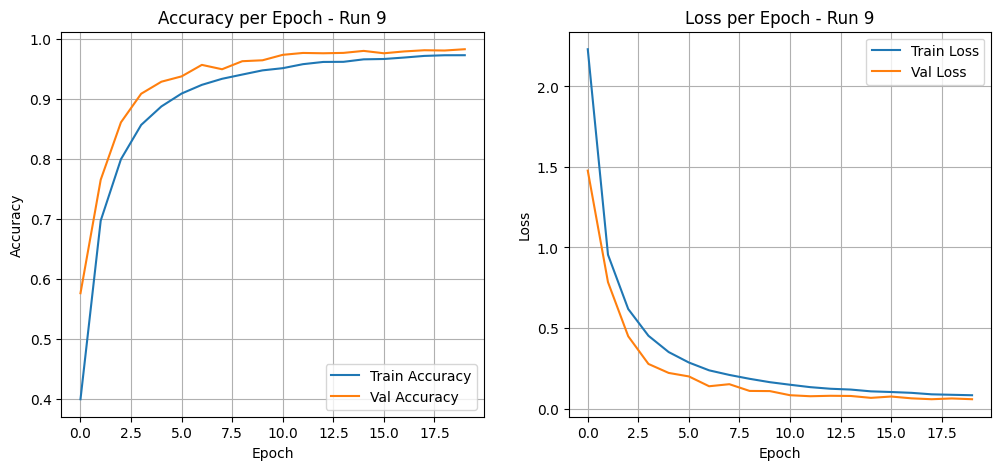

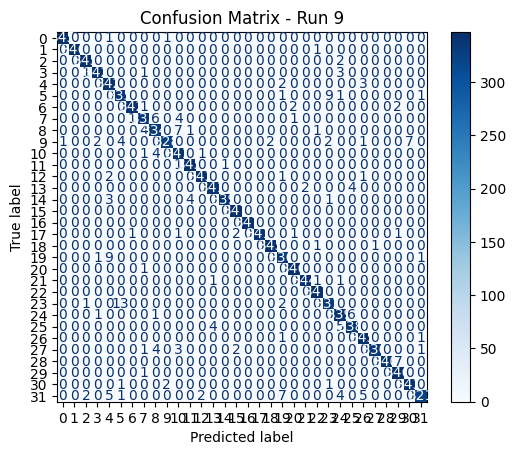


🚀 Run 10/10


/tmp/ipython-input-3345950361.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


694/694 ━━━━━━━━━━━━━━━━━━━━ 87s 107ms/step - accuracy: 0.2496 - loss: 3.0786 - val_accuracy: 0.5534 - val_loss: 1.5599 - learning_rate: 1.0000e-04
Epoch 2/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.6625 - loss: 1.0699 - val_accuracy: 0.7706 - val_loss: 0.7563 - learning_rate: 1.0000e-04
Epoch 3/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.7789 - loss: 0.6747 - val_accuracy: 0.8691 - val_loss: 0.4147 - learning_rate: 1.0000e-04
Epoch 4/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - accuracy: 0.8450 - loss: 0.4817 - val_accuracy: 0.9132 - val_loss: 0.2741 - learning_rate: 1.0000e-04
Epoch 5/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 101ms/step - accuracy: 0.8854 - loss: 0.3562 - val_accuracy: 0.9317 - val_loss: 0.2088 - learning_rate: 1.0000e-04
Epoch 6/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 74s 106ms/step - accuracy: 0.9036 - loss: 0.3011 - val_accuracy: 0.9416 - val_loss: 0.1854 - learning_rate: 1.0000e-04
Epoch 7/20
694/694 ━━━━━━━━━━━━━━━━━━━━ 71s 102ms/step - ac

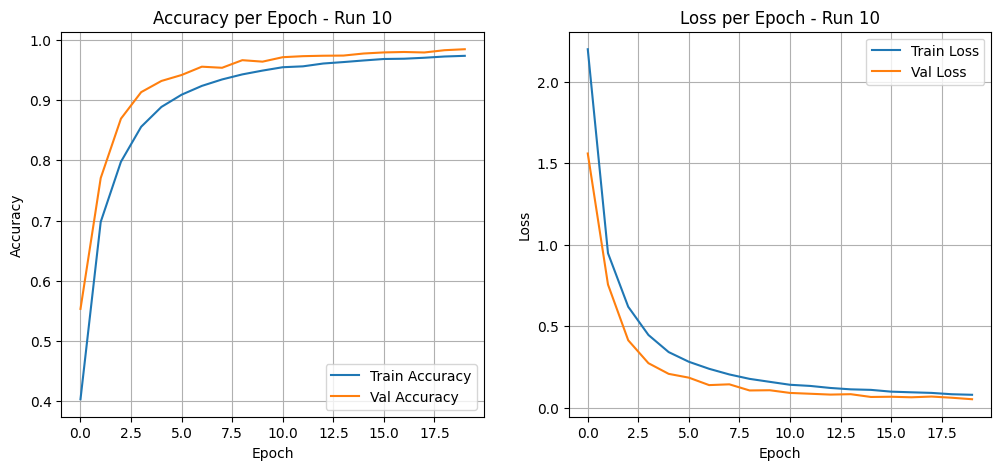

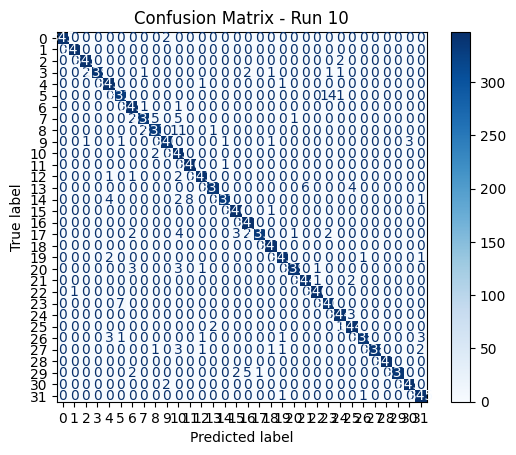


✅ جميع النتائج بعد 10 Runs:
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.984600  0.051388  0.984108  0.999900     0.984601   
1    2      0.985411  0.050550  0.984944  0.999890     0.985407   
2    3      0.984510  0.051002  0.984014  0.999895     0.984508   
3    4      0.984150  0.057354  0.983644  0.999846     0.984154   
4    5      0.980457  0.063336  0.979833  0.999834     0.980464   
5    6      0.983429  0.053651  0.982901  0.999895     0.983433   
6    7      0.982529  0.054259  0.981974  0.999918     0.982528   
7    8      0.983429  0.056249  0.982903  0.999856     0.983437   
8    9      0.981178  0.057809  0.980578  0.999888     0.981174   
9   10      0.984420  0.053254  0.983926  0.999901     0.984441   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.984733         0.984600       1264.833052      1248.578125  
1            0.985516         0.985411       1241.182733       424.230469  
2    

In [ ]:
import gc, time, psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
from sklearn.metrics import (matthews_corrcoef, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score, recall_score)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

results = []

for run in range(1, 11):  # 10 runs
    print(f"\n🚀 Run {run}/10")

    # --- قياس الوقت والذاكرة قبل التدريب ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    # --- بناء الموديل ---
    model = build_mobilenetv2(input_shape, num_classes)

    early_stop = EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
    lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

    # --- تدريب الموديل ---
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=64),
        validation_data=(X_val, y_val),
        epochs=20,
        callbacks=[early_stop, lr_reduce],
        verbose=1
    )

    # --- قياس الوقت والذاكرة بعد التدريب ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)
    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    # --- تقييم الموديل ---
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

    # --- تنبؤ ---
    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    try:
        roc_auc = roc_auc_score(y_val_bin, y_pred_probs, average='macro', multi_class='ovr')
    except:
        roc_auc = np.nan

    # --- Weighted Metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    # --- حفظ النتيجة ---
    run_result = {
        "Run": run,
        "Val_Accuracy": val_acc,
        "Val_Loss": val_loss,
        "MCC": mcc,
        "ROC_AUC": roc_auc,
        "F1_Weighted": f1_w,
        "Precision_Weighted": precision_w,
        "Recall_Weighted": recall_w,
        "Training_Time(s)": train_time,
        "Memory_Used(MB)": train_memory
    }
    results.append(run_result)

    print(f"\n📊 Results Run {run}: "
          f"Acc={val_acc:.4f}, Loss={val_loss:.4f}, MCC={mcc:.4f}, "
          f"ROC_AUC={roc_auc:.4f}, F1={f1_w:.4f}, "
          f"Prec={precision_w:.4f}, Recall={recall_w:.4f}, "
          f"Time={train_time:.2f}s, Mem={train_memory:.2f}MB")

    # --- رسم Accuracy و Loss لكل Epoch ---
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Accuracy per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss per Epoch - Run {run}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- تنظيف الميموري ---
    del model, history, y_pred, y_pred_probs
    K.clear_session()
    gc.collect()

# --- تحويل ل DataFrame ---
df_results = pd.DataFrame(results)
print("\n✅ جميع النتائج بعد 10 Runs:")
print(df_results)

# --- حفظ النتائج ---
df_results.to_excel("mobilenetv2_metrics_results.xlsx", index=False)
print("\n💾 Saved to mobilenetv2_metrics_results.xlsx")


In [ ]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/Mobilenet_over.xlsx', index=False)
print("✅ Results saved to mobilenetv2_over_analysis.xlsx")
print(df_results)


✅ Results saved to mobilenetv2_over_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.984600  0.051388  0.984108  0.999900     0.984601   
1    2      0.985411  0.050550  0.984944  0.999890     0.985407   
2    3      0.984510  0.051002  0.984014  0.999895     0.984508   
3    4      0.984150  0.057354  0.983644  0.999846     0.984154   
4    5      0.980457  0.063336  0.979833  0.999834     0.980464   
5    6      0.983429  0.053651  0.982901  0.999895     0.983433   
6    7      0.982529  0.054259  0.981974  0.999918     0.982528   
7    8      0.983429  0.056249  0.982903  0.999856     0.983437   
8    9      0.981178  0.057809  0.980578  0.999888     0.981174   
9   10      0.984420  0.053254  0.983926  0.999901     0.984441   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.984733         0.984600       1264.833052      1248.578125  
1            0.985516         0.985411       1241.182733    

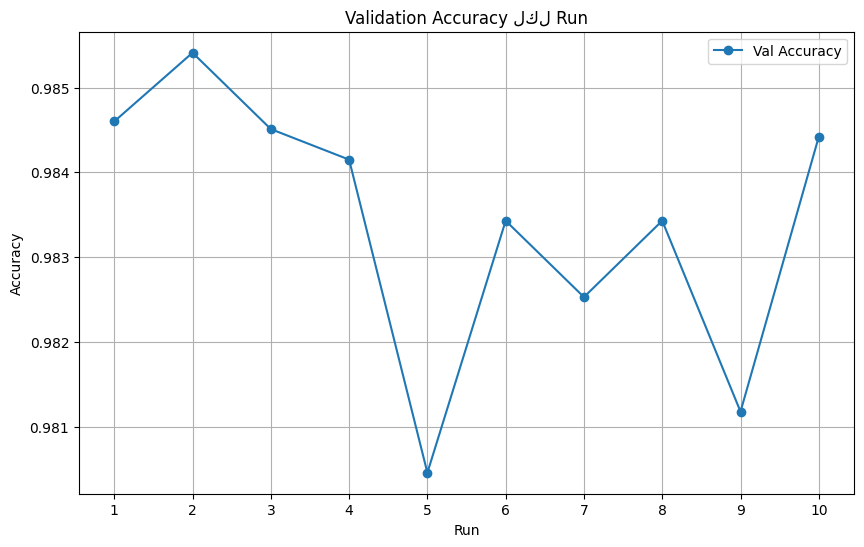

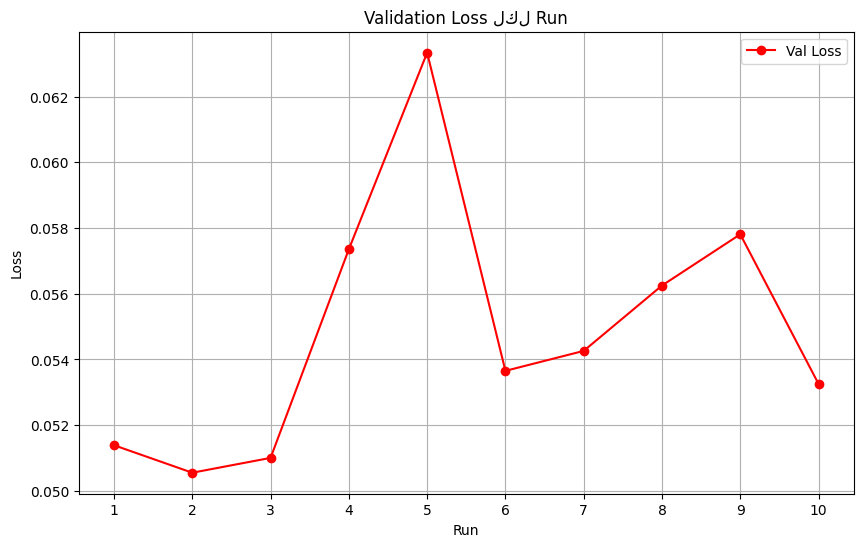

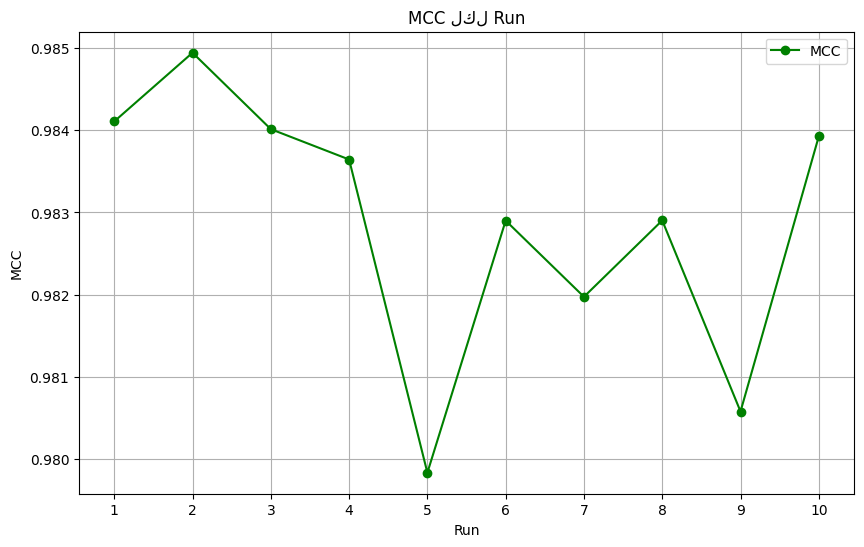

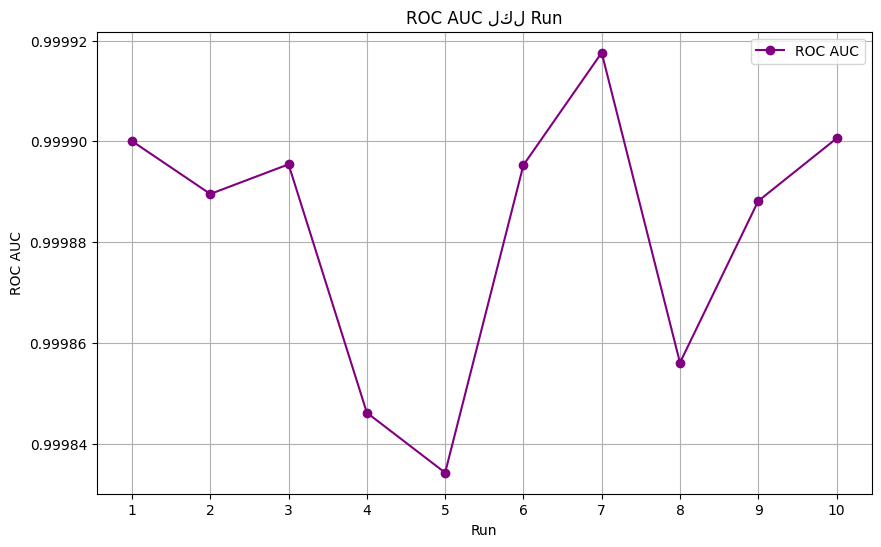

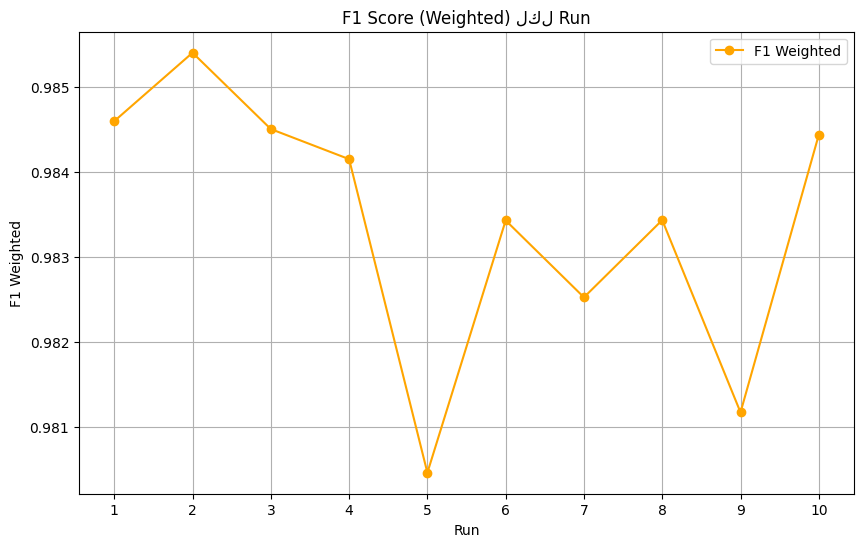

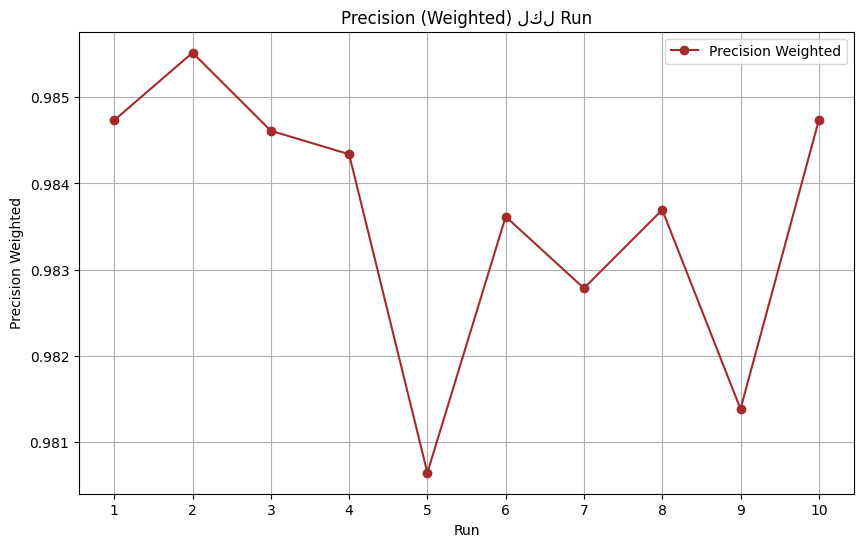

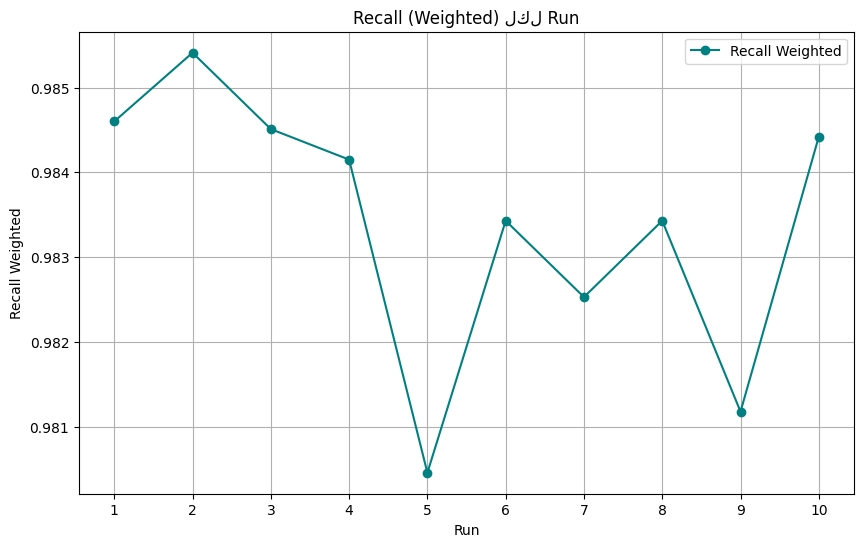

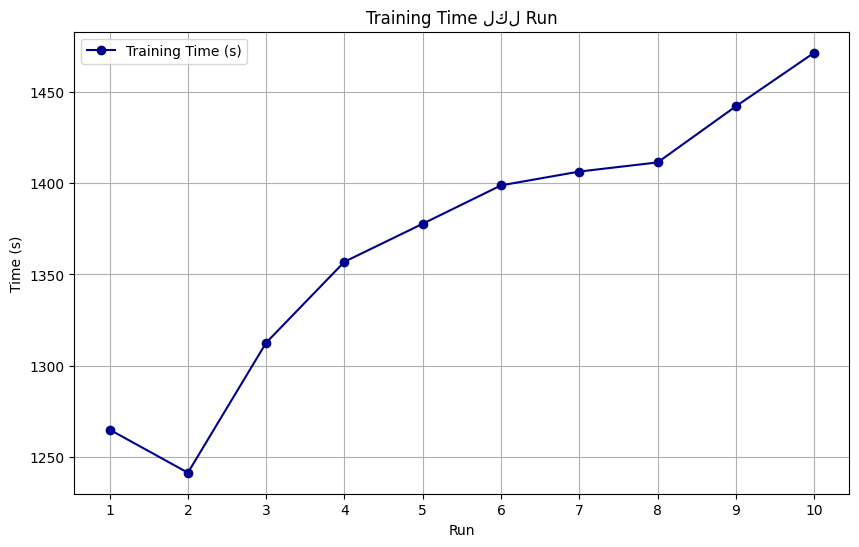

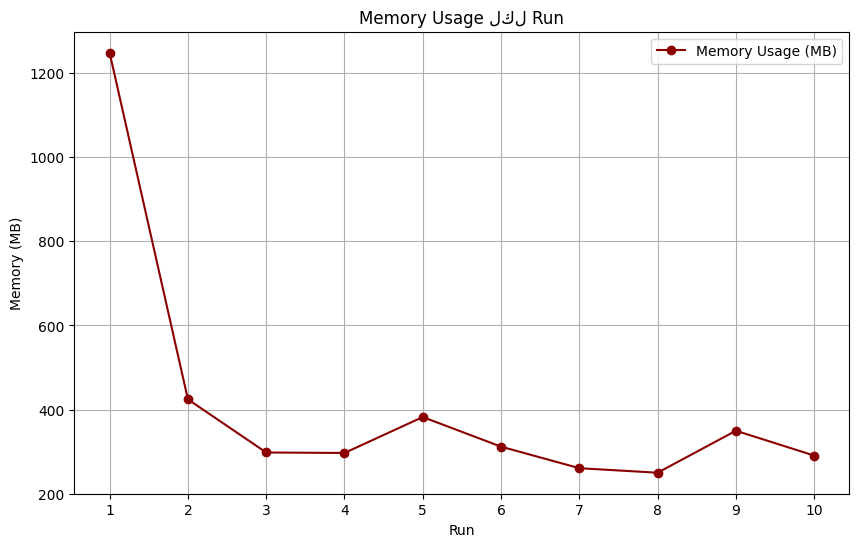

In [ ]:
import matplotlib.pyplot as plt

# --- رسم Accuracy لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Val Accuracy')
plt.title("Validation Accuracy لكل Run")
plt.xlabel("Run")
plt.ylabel("Accuracy")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Loss لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Val_Loss'], marker='o', color='red', label='Val Loss')
plt.title("Validation Loss لكل Run")
plt.xlabel("Run")
plt.ylabel("Loss")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم MCC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['MCC'], marker='o', color='green', label='MCC')
plt.title("MCC لكل Run")
plt.xlabel("Run")
plt.ylabel("MCC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم ROC_AUC لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['ROC_AUC'], marker='o', color='purple', label='ROC AUC')
plt.title("ROC AUC لكل Run")
plt.xlabel("Run")
plt.ylabel("ROC AUC")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()
# --- رسم F1 لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['F1_Weighted'], marker='o', color='orange', label='F1 Weighted')
plt.title("F1 Score (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("F1 Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Precision لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Precision_Weighted'], marker='o', color='brown', label='Precision Weighted')
plt.title("Precision (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Precision Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Recall لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Recall_Weighted'], marker='o', color='teal', label='Recall Weighted')
plt.title("Recall (Weighted) لكل Run")
plt.xlabel("Run")
plt.ylabel("Recall Weighted")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Training Time لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', color='darkblue', label='Training Time (s)')
plt.title("Training Time لكل Run")
plt.xlabel("Run")
plt.ylabel("Time (s)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()

# --- رسم Memory Usage لكل رن ---
plt.figure(figsize=(10, 6))
plt.plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='o', color='darkred', label='Memory Usage (MB)')
plt.title("Memory Usage لكل Run")
plt.xlabel("Run")
plt.ylabel("Memory (MB)")
plt.xticks(df_results['Run'])
plt.grid(True)
plt.legend()
plt.show()


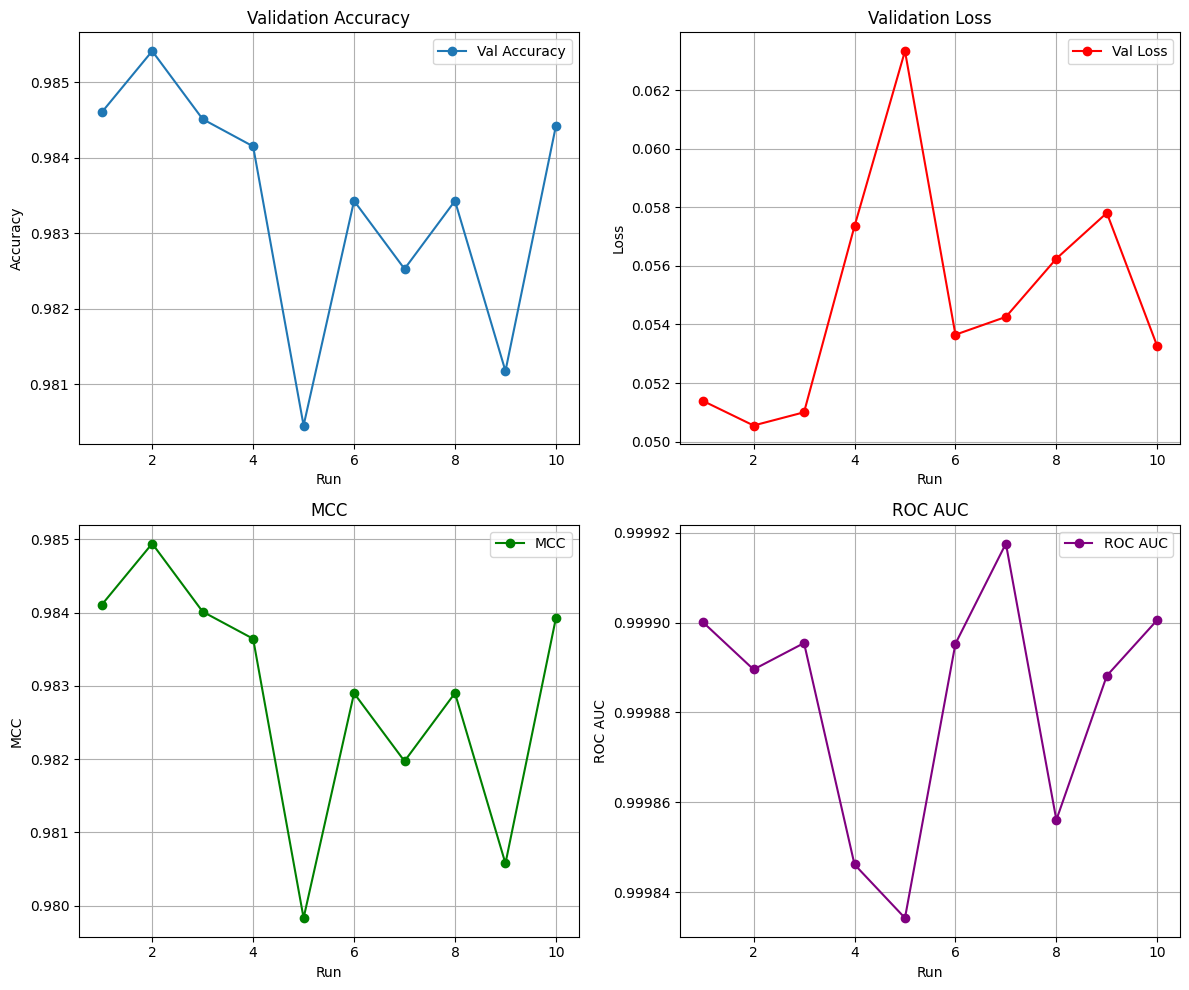

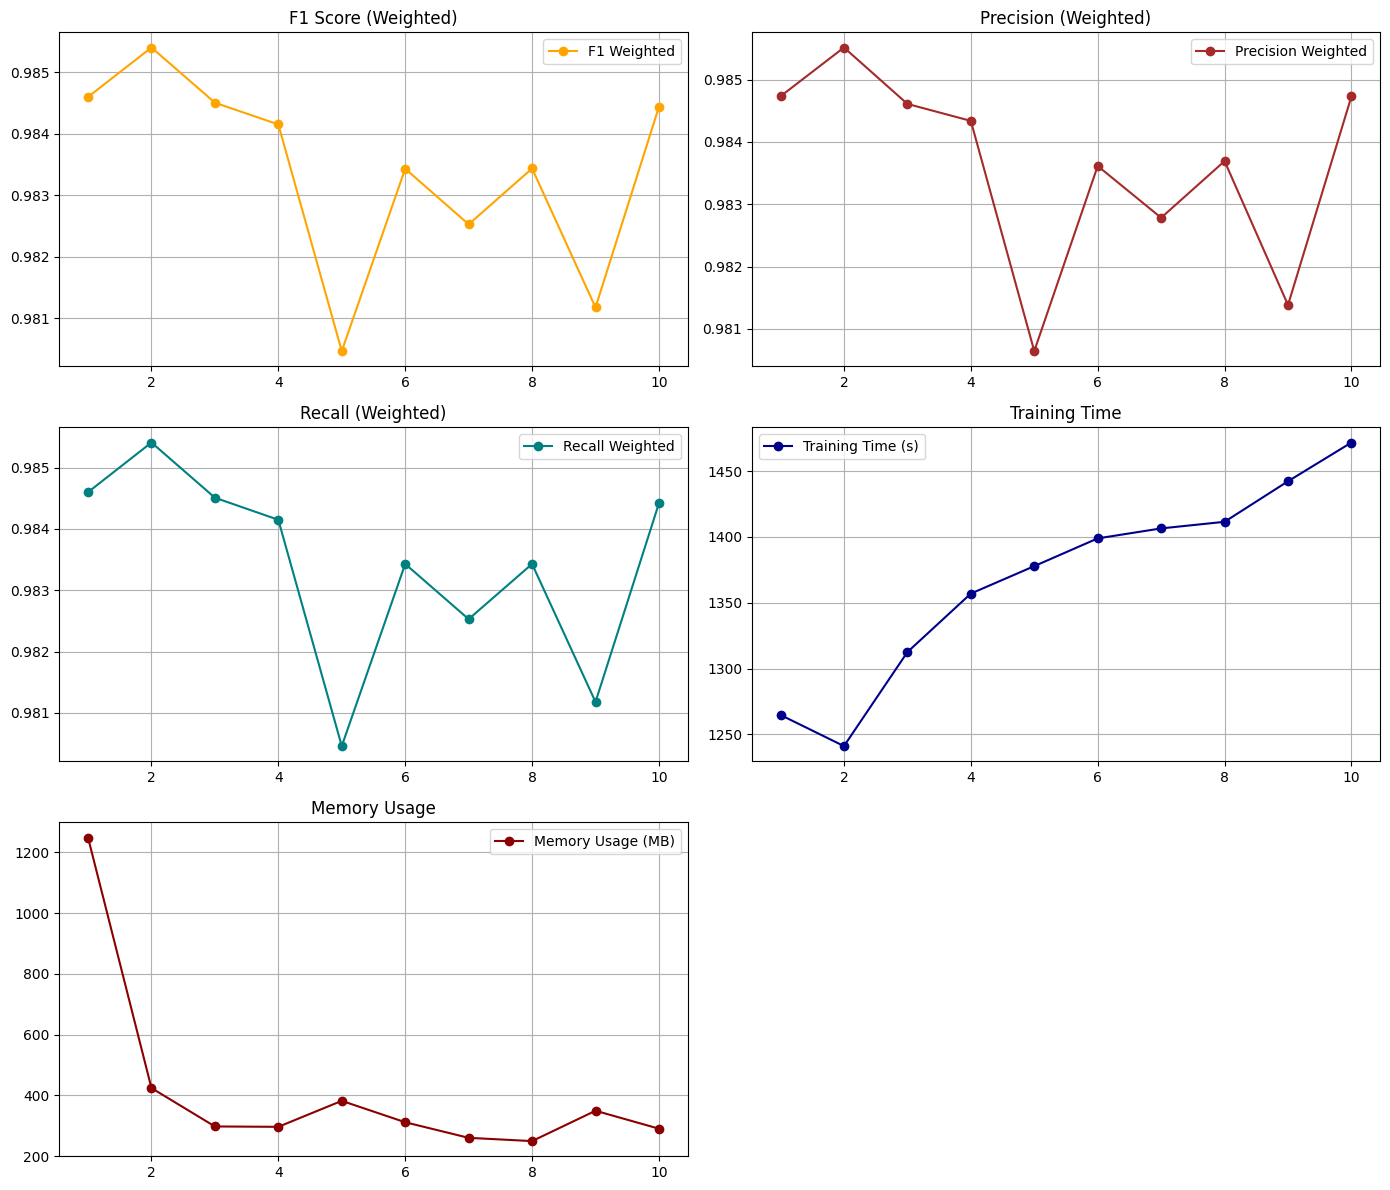

In [ ]:
import matplotlib.pyplot as plt

# --- مجموعة 1: Accuracy, Loss, ROC_AUC, MCC ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Accuracy
axs[0, 0].plot(df_results['Run'], df_results['Val_Accuracy'], marker='o', label='Val Accuracy')
axs[0, 0].set_title("Validation Accuracy")
axs[0, 0].set_xlabel("Run")
axs[0, 0].set_ylabel("Accuracy")
axs[0, 0].grid(True)
axs[0, 0].legend()

# Loss
axs[0, 1].plot(df_results['Run'], df_results['Val_Loss'], marker='o', color='red', label='Val Loss')
axs[0, 1].set_title("Validation Loss")
axs[0, 1].set_xlabel("Run")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].grid(True)
axs[0, 1].legend()

# MCC
axs[1, 0].plot(df_results['Run'], df_results['MCC'], marker='o', color='green', label='MCC')
axs[1, 0].set_title("MCC")
axs[1, 0].set_xlabel("Run")
axs[1, 0].set_ylabel("MCC")
axs[1, 0].grid(True)
axs[1, 0].legend()

# ROC_AUC
axs[1, 1].plot(df_results['Run'], df_results['ROC_AUC'], marker='o', color='purple', label='ROC AUC')
axs[1, 1].set_title("ROC AUC")
axs[1, 1].set_xlabel("Run")
axs[1, 1].set_ylabel("ROC AUC")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()


# --- مجموعة 2: باقي المقاييس ---
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# F1
axs[0, 0].plot(df_results['Run'], df_results['F1_Weighted'], marker='o', color='orange', label='F1 Weighted')
axs[0, 0].set_title("F1 Score (Weighted)")
axs[0, 0].grid(True)
axs[0, 0].legend()

# Precision
axs[0, 1].plot(df_results['Run'], df_results['Precision_Weighted'], marker='o', color='brown', label='Precision Weighted')
axs[0, 1].set_title("Precision (Weighted)")
axs[0, 1].grid(True)
axs[0, 1].legend()

# Recall
axs[1, 0].plot(df_results['Run'], df_results['Recall_Weighted'], marker='o', color='teal', label='Recall Weighted')
axs[1, 0].set_title("Recall (Weighted)")
axs[1, 0].grid(True)
axs[1, 0].legend()

# Training Time
axs[1, 1].plot(df_results['Run'], df_results['Training_Time(s)'], marker='o', color='darkblue', label='Training Time (s)')
axs[1, 1].set_title("Training Time")
axs[1, 1].grid(True)
axs[1, 1].legend()

# Memory Usage
axs[2, 0].plot(df_results['Run'], df_results['Memory_Used(MB)'], marker='o', color='darkred', label='Memory Usage (MB)')
axs[2, 0].set_title("Memory Usage")
axs[2, 0].grid(True)
axs[2, 0].legend()

# إخفاء subplot الفاضي
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=468060f647d91c18e4d8dd6030be7b3a7d7d515d95b845f3b603e4165c7cfc94
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Sequential Input Shape: T=10 × 64x64x1


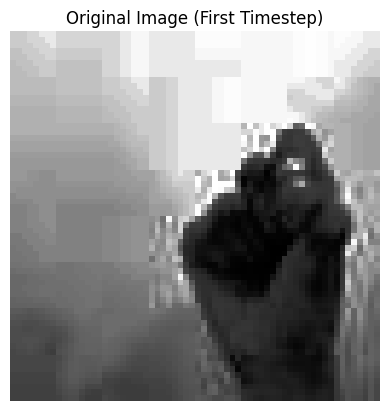

Predicted class: fa (0.90)


  0%|          | 0/1000 [00:00<?, ?it/s]

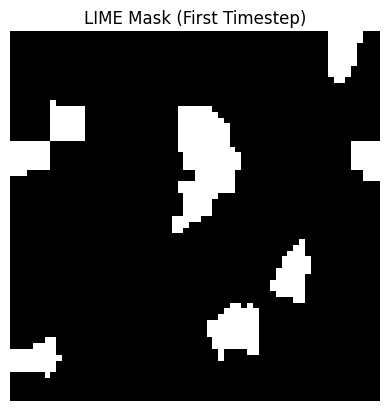

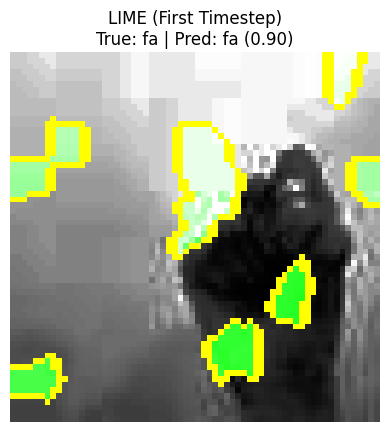

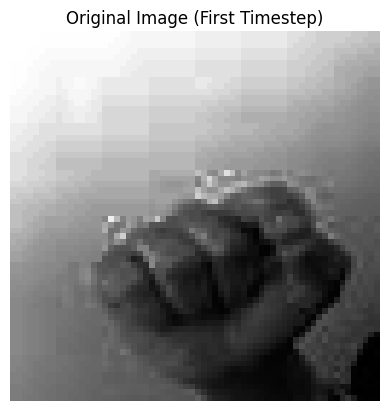

Predicted class: fa (0.99)


  0%|          | 0/1000 [00:00<?, ?it/s]

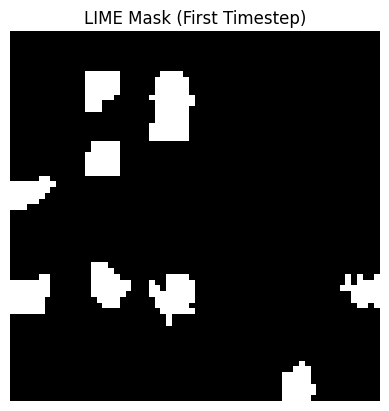

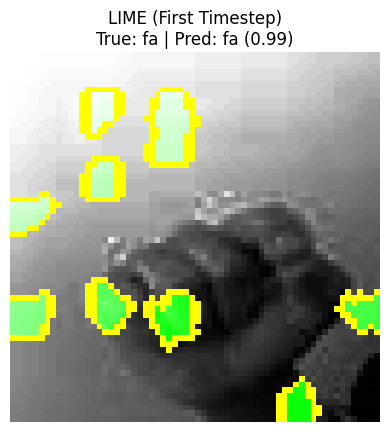

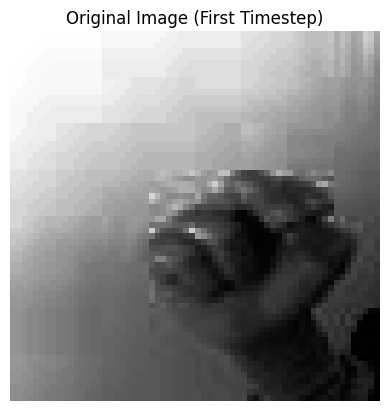

Predicted class: gaaf (0.98)


  0%|          | 0/1000 [00:00<?, ?it/s]

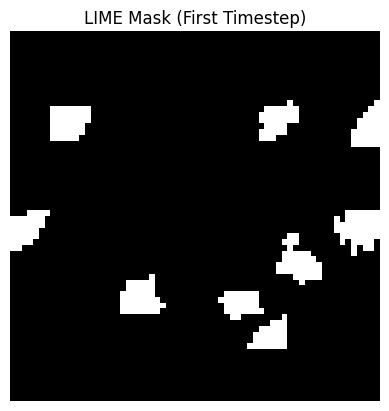

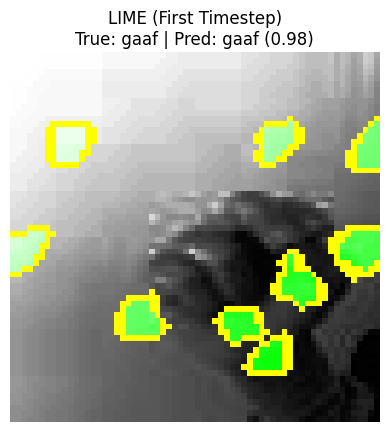

In [ ]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize
from skimage.color import rgb2gray  # Add for grayscale conversion

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
full_input_shape = model.input_shape  # e.g., (None, 10, 64, 64, 1)
input_shape = full_input_shape[1:]    # Remove batch dim: e.g., (10, 64, 64, 1)

T = 1
if len(input_shape) == 4 and input_shape[0] == 10 and input_shape[-1] == 1:
    T, H, W, C = input_shape  # T=10 timesteps, H/W=64, C=1 (grayscale)
    print(f"📐 Sequential Input Shape: T={T} × {H}x{W}x{C}")
elif len(input_shape) == 1:
    # 1D input (flattened): infer H, W, C assuming square grayscale (C=1) or adjust as needed
    features = input_shape[0]
    H = int(np.sqrt(features))  # Assume square; adjust if rectangular
    W = H
    C = 1  # Grayscale; set to 3 if flattened RGB
    print(f"📐 Inferred Input Shape (flattened): T={T} × {H}x{W}x{C} (total features: {features})")
elif len(input_shape) == 3:
    H, W, C = input_shape
    print(f"📐 Input Shape: T={T} × {H}x{W}x{C}")
else:
    raise ValueError(f"Unsupported input shape: {input_shape}")

# دالة تجهيز الصور زي التدريب (updated for sequential input)
def preprocess_batch(images):
    # images: list of data items, each potentially (T, H, W, C) or raw
    out = []
    for item in images:
        item = np.asarray(item)
        if item.ndim == 4 and item.shape == input_shape:  # Already (T, H, W, 1)
            im = item
        elif item.ndim == 2:  # Grayscale 2D: expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps if input is static
        elif item.ndim == 3 and item.shape[-1] == 1:  # (H, W, 1): expand to (T, H, W, 1)
            im = np.expand_dims(item, axis=0)  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)
        elif item.ndim == 3 and item.shape[-1] == 3:  # RGB image: convert to grayscale first
            gray = rgb2gray(item)  # Convert to (H, W)
            im = np.expand_dims(gray, axis=(0, -1))  # (1, H, W, 1)
            if T > 1:
                im = np.repeat(im, T, axis=0)  # Duplicate across timesteps
        else:
            # Fallback: assume it's the full sequence or handle differently
            if item.ndim == 5 and item.shape[1:] == input_shape:
                im = item[0]  # Take first batch if accidentally batched
            else:
                raise ValueError(f"Unexpected item shape: {item.shape}")

        # Resize each timestep if needed (preserves T)
        resized = np.zeros(input_shape, dtype='float32')
        for t in range(T):
            frame = im[t, :, :, 0] if C == 1 else im[t]
            frame_resized = resize(frame, (H, W), preserve_range=True, anti_aliasing=True).astype('float32')
            resized[t, :, :, 0] = frame_resized
        im = resized

        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(X_val), size=3, replace=False)

for idx in indices:
    data_item = X_val[idx]  # Assume (T, H, W, C)

    # تجهيز نسخة RGB للعرض (use first timestep as representative)
    if data_item.ndim == 4:
        frame = data_item[0]  # First timestep
    else:
        frame = data_item
    if frame.ndim == 2 or frame.shape[-1] == 1:
        image_rgb = np.repeat(frame[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = frame[..., :3]

    # --- عرض الصورة الأصلية (first frame) ---
    plt.figure()
    plt.imshow(image_rgb, cmap='gray' if C == 1 else None)
    plt.title("Original Image (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([data_item]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME (on first frame as static image) ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),  # Use double for precision
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask, cmap='gray')
    plt.title("LIME Mask (First Timestep)")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME (First Timestep)\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/my_modelmobilenet_over.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val_mobilenet_over.npy', X_val)
np.save('/content/drive/MyDrive/alphabet/y_val_mobilenet_over.npy', y_val)
